# Detekcija anomalija u financijskim transakcijama: duboki autoenkoder

Ova bilježnica implementira i evaluira duboki autoenkoder (engl. *Autoencoder*) za detekciju prijevarnih transakcija, korištenjem skupa podataka Credit Card Fraud Detection (ULB, Kaggle) te biblioteke Keras/TensorFlow.

Struktura prati poglavlje 4.5. završnog rada *Izrada prototipa sustava za detekciju anomalija u financijskim sustavima u stvarnom vremenu primjenom metoda strojnog učenja*. Kronološka podjela podataka i metrike evaluacije usklađene su s bilježnicom za algoritam izolacijskih stabala radi izravne usporedbe rezultata (poglavlje 4.6.).

In [1]:
#!pip install -q kagglehub scikit-learn pandas matplotlib seaborn
!pip install -q tensorflow

import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import (
    precision_score, recall_score, f1_score, confusion_matrix,
    roc_auc_score, average_precision_score, roc_curve, precision_recall_curve
)
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

RANDOM_STATE = 42
tf.random.set_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

## 1. Učitavanje podataka

In [2]:
path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")

df = pd.read_csv(f"{path}/creditcard.csv")
print(df.shape)
df.head()

Using Colab cache for faster access to the 'creditcardfraud' dataset.
(284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## 2. Predobrada podataka

Kao i kod algoritma izolacijskih stabala, Time i Amount skaliramo, a podjelu na trening i test skup provodimo kronološki. Ključna razlika: trening skup sadrži isključivo legitimne transakcije (Class = 0), u skladu s polunadziranim pristupom (autoenkoder uči rekonstruirati samo normalno ponašanje), pa transakcije koje ne uspije vjerno rekonstruirati tretiramo kao potencijalne anomalije.

In [3]:
split_idx = int(len(df) * 0.7)
train_df = df.iloc[:split_idx].copy()
test_df = df.iloc[split_idx:].copy()

In [4]:
amount_scaler = RobustScaler()
train_df['Amount_scaled'] = amount_scaler.fit_transform(train_df[['Amount']])
test_df['Amount_scaled'] = amount_scaler.transform(test_df[['Amount']])

time_scaler = RobustScaler()
train_df['Time_scaled'] = time_scaler.fit_transform(train_df[['Time']])
test_df['Time_scaled'] = time_scaler.transform(test_df[['Time']])

feature_cols = [c for c in df.columns if c.startswith('V')] + ['Amount_scaled', 'Time_scaled']

In [5]:
X_train_normal = train_df[train_df['Class'] == 0][feature_cols].values

val_split = int(len(X_train_normal) * 0.9)
X_train = X_train_normal[:val_split]
X_val = X_train_normal[val_split:]

X_test = test_df[feature_cols].values
y_test = test_df['Class'].values

print(f"Train (just legitimate): {X_train.shape}")
print(f"Validation (just legitimate): {X_val.shape}")
print(f"Test (both classes): {X_test.shape}, Fraud rate: {y_test.mean() * 100:.4f} %")

Train (just legitimate): (179082, 30)
Validation (just legitimate): (19898, 30)
Test (both classes): (85443, 30), Fraud rate: 0.1264 %


## 3. Arhitektura autoenkodera

Simetrična arhitektura enkoder – usko grlo – dekoder. Ulazna dimenzija odgovara broju značajki (30: V1–V28, Amount_scaled, Time_scaled).

In [6]:
input_dim = X_train.shape[1]

autoencoder = keras.Sequential([
    layers.Input(shape=(input_dim,)),
    layers.Dense(20, activation='relu'),
    layers.Dense(14, activation='relu'),
    layers.Dense(8, activation='relu', name='bottleneck'),
    layers.Dense(14, activation='relu'),
    layers.Dense(20, activation='relu'),
    layers.Dense(input_dim, activation='linear')
])

autoencoder.compile(optimizer='adam', loss='mse')
autoencoder.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 20)             │           620 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 14)             │           294 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bottleneck (Dense)              │ (None, 8)              │           120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 14)             │           126 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 20)             │           300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 30)             │           630 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,090 (8.16 KB)

 Trainable params: 2,090 (8.16 KB)

 Non-trainable params: 0 (0.00 B)

## 4. Treniranje

Epoch 1/50
700/700 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.7574 - val_loss: 0.6213
Epoch 2/50
700/700 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.4037 - val_loss: 0.4768
Epoch 3/50
700/700 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.3399 - val_loss: 0.4336
Epoch 4/50
700/700 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.3107 - val_loss: 0.4057
Epoch 5/50
700/700 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.2907 - val_loss: 0.3855
Epoch 6/50
700/700 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.2780 - val_loss: 0.3690
Epoch 7/50
700/700 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.2698 - val_loss: 0.3656
Epoch 8/50
700/700 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.2640 - val_loss: 0.3607
Epoch 9/50
700/700 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.2595 - val_loss: 0.3488
Epoch 10/50
700/700 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.2556 - val_loss: 0.3463
Epoch 11/50
700/700 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.2515 - val_loss: 0.3398
Epoch 12/50
700/700 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step

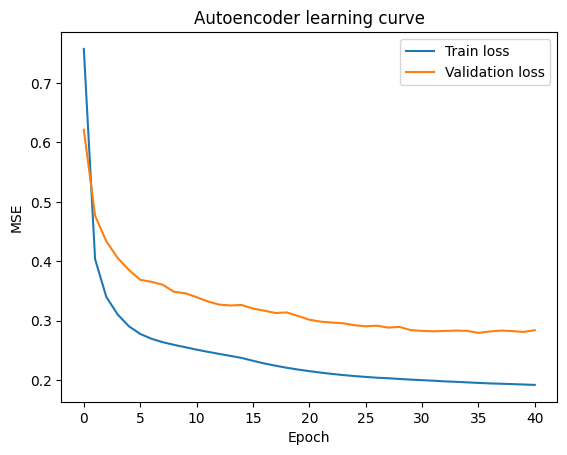

In [7]:
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=5, restore_best_weights=True
)

history = autoencoder.fit(
    X_train, X_train,
    validation_data=(X_val, X_val),
    epochs=50,
    batch_size=256,
    shuffle=True,
    callbacks=[early_stop],
    verbose=1
)

plt.plot(history.history['loss'], label='Train loss')
plt.plot(history.history['val_loss'], label='Validation loss')
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.title('Autoencoder learning curve')
plt.legend()
plt.show()

## 5. Pogreška rekonstrukcije i određivanje praga

Prag postavljamo na temelju percentila pogreške rekonstrukcije na validacijskom skupu, koji sadrži isključivo legitimne transakcije (npr. 99. percentil znači da otprilike 1 % legitimnih transakcija u validaciji prelazi prag). To je polazna točka koju je moguće dodatno podešavati ovisno o željenom odnosu preciznosti i odziva.

In [8]:
X_test_pred = autoencoder.predict(X_test)
reconstruction_error = np.mean(np.square(X_test - X_test_pred), axis=1)

X_val_pred = autoencoder.predict(X_val)
val_error = np.mean(np.square(X_val - X_val_pred), axis=1)
threshold = np.percentile(val_error, 99)
print(f"Reconstruction error threshold: {threshold:.4f}")

y_pred = (reconstruction_error > threshold).astype(int)

2671/2671 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step
622/622 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
Reconstruction error threshold: 1.3905


## 6. Evaluacija

Precision: 0.0883
Recall: 0.7037
F1-score: 0.1569
ROC-AUC: 0.9387
PR-AUC: 0.0998


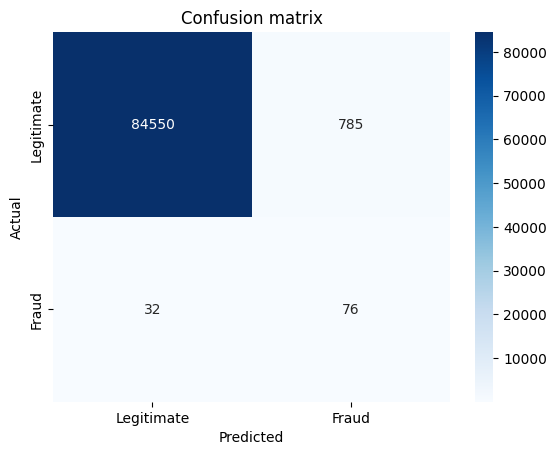

In [9]:
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, reconstruction_error)
pr_auc = average_precision_score(y_test, reconstruction_error)

print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")
print(f"ROC-AUC: {roc_auc:.4f}")
print(f"PR-AUC: {pr_auc:.4f}")

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Legitimate', 'Fraud'], yticklabels=['Legitimate', 'Fraud'])
plt.title('Confusion matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

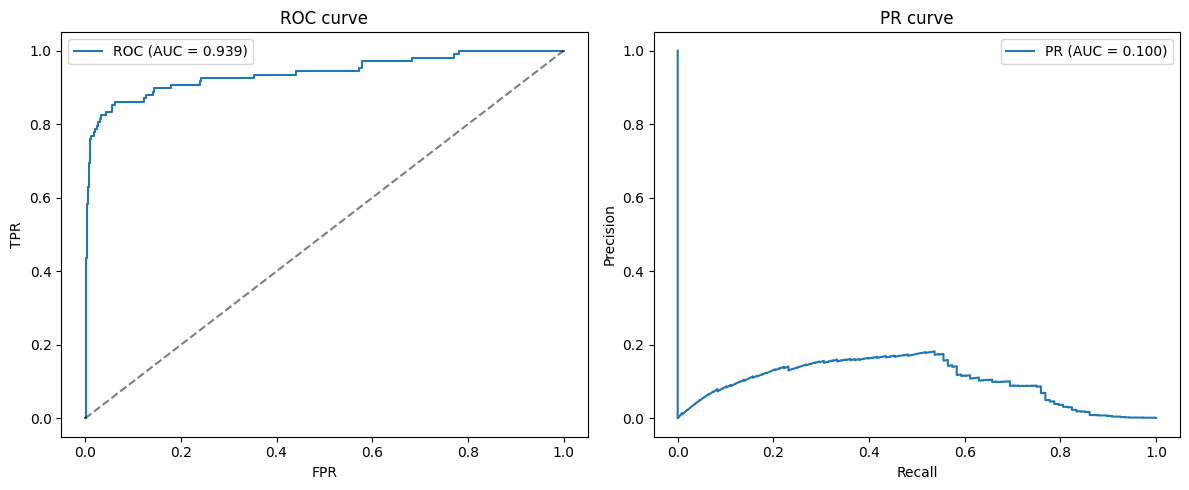

In [10]:
fpr, tpr, _ = roc_curve(y_test, reconstruction_error)
prec_curve, rec_curve, _ = precision_recall_curve(y_test, reconstruction_error)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].plot(fpr, tpr, label=f'ROC (AUC = {roc_auc:.3f})')
axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.5)
axes[0].set_xlabel('FPR')
axes[0].set_ylabel('TPR')
axes[0].set_title('ROC curve')
axes[0].legend()

axes[1].plot(rec_curve, prec_curve, label=f'PR (AUC = {pr_auc:.3f})')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('PR curve')
axes[1].legend()
plt.tight_layout()
plt.show()

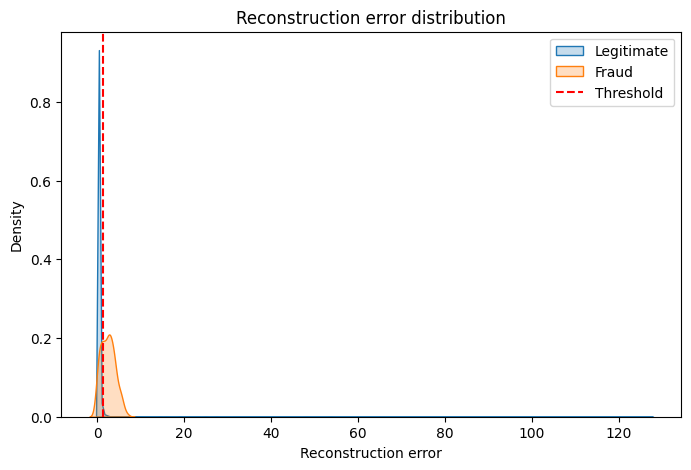

In [11]:
plt.figure(figsize=(8, 5))
sns.kdeplot(reconstruction_error[y_test == 0], label='Legitimate', fill=True)
sns.kdeplot(reconstruction_error[y_test == 1], label='Fraud', fill=True)
plt.axvline(threshold, color='red', linestyle='--', label='Threshold')
plt.xlabel('Reconstruction error')
plt.title('Reconstruction error distribution')
plt.legend()
plt.show()

## 7. Vizualizacija naučene reprezentacije (2D usko grlo)

Kako bismo intuitivno prikazali što autoenkoder uči, treniramo zaseban, ilustrativni autoenkoder s uskim grlom veličine samo 2 neurona (za razliku od stvarnog modela čije je usko grlo veličine 8). Ovo je isključivo u svrhu vizualizacije, odvojeno od modela korištenog za stvarnu evaluaciju. Nakon treniranja se primjenjuje samo enkoderski dio na testne podatke, čime se dobiva njihova 2D reprezentacija, prikazana u ravnini obojena prema stvarnoj klasi.

2671/2671 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step


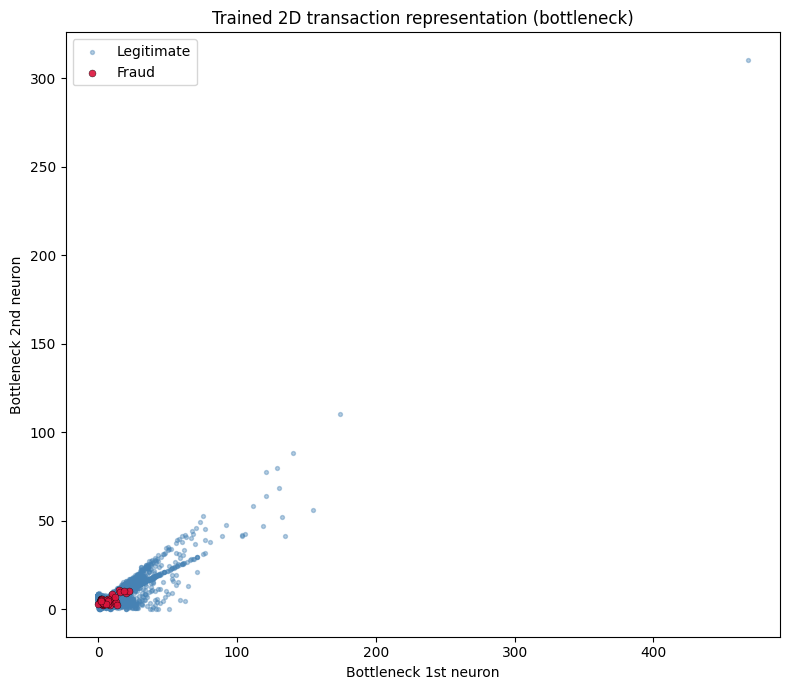

In [12]:
encoder_viz = keras.Sequential([
    layers.Input(shape=(input_dim,)),
    layers.Dense(20, activation='relu'),
    layers.Dense(14, activation='relu'),
    layers.Dense(2, activation='relu', name='bottleneck_2d')
])
decoder_viz = keras.Sequential([
    layers.Input(shape=(2,)),
    layers.Dense(14, activation='relu'),
    layers.Dense(20, activation='relu'),
    layers.Dense(input_dim, activation='linear')
])
autoencoder_viz = keras.Sequential([encoder_viz, decoder_viz])
autoencoder_viz.compile(optimizer='adam', loss='mse')

autoencoder_viz.fit(
    X_train, X_train,
    validation_data=(X_val, X_val),
    epochs=30,
    batch_size=256,
    shuffle=True,
    verbose=0
)

X_test_2d = encoder_viz.predict(X_test)

plt.figure(figsize=(8, 7))
plt.scatter(X_test_2d[y_test == 0, 0], X_test_2d[y_test == 0, 1],
            c='steelblue', s=8, alpha=0.4, label='Legitimate')
plt.scatter(X_test_2d[y_test == 1, 0], X_test_2d[y_test == 1, 1],
            c='crimson', s=25, alpha=0.9, label='Fraud', edgecolors='k', linewidths=0.3)
plt.xlabel('Bottleneck 1st neuron')
plt.ylabel('Bottleneck 2nd neuron')
plt.title('Trained 2D transaction representation (bottleneck)')
plt.legend()
plt.tight_layout()
plt.show()

## 8. Spremanje modela

In [13]:
autoencoder.save('autoencoder_model.keras')
print("Model spremljen.")

Model spremljen.
